# 🛡️ Phishing Website Detection — Novel Two-Stream Stacked Ensemble

**Dataset:** CompPhish (Mendeley Data) — 15,358 samples, 70 features
**Files needed:** `All_Features_threshold90.xlsx` (features + labels), `Mapping_File.xlsx` (serial_number → URL → label)

### What this notebook does
1. Loads the real CompPhish dataset
2. Engineers a **novel "Suspicion Score"** feature (our contribution)
3. Splits the 70 features into two groups: **URL-based** (how the link looks) and **HTML-based** (what the page contains)
4. Trains a **stacked ensemble** — two base models feed a meta-learner
5. Compares against single-model baselines
6. Shows full evaluation: AUC, F1, confusion matrix, SHAP
7. Lets you predict any row by `serial_number`, verified against the Mapping File

### Novel hypothesis
Combining URL-signal and HTML-signal via stacking outperforms any single model because the two feature groups carry complementary information about phishing behaviour.

### Curriculum map
Preprocessing · Feature Engineering · Supervised Classification · Ensemble/Stacking · Evaluation · Explainability (SHAP)

---
**⚠️ Before running in Colab:** upload `All_Features_threshold90.xlsx` and `Mapping_File.xlsx` using the folder icon in the left sidebar (Files → Upload), or mount Google Drive if you'd rather keep them there.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGB = False
    print("[INFO] LightGBM not found — using GradientBoostingClassifier instead.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("[INFO] SHAP not installed — skipping explainability plots.")

SEED = 42
np.random.seed(SEED)

## 1. Load Dataset

**Colab note:** the paths below are now relative filenames (fixed from the original hardcoded Windows path). Upload both `.xlsx` files to the Colab session's file storage first — otherwise this cell will raise `FileNotFoundError`.

In [2]:
# NOTE: In Colab, upload these two files first (sidebar folder icon → Upload,
# or drag-and-drop into the Files pane), then this relative path will work.
# If you'd rather use Google Drive instead, mount it with:
#   from google.colab import drive; drive.mount('/content/drive')
# and point these paths at the mounted location.
FEATURES_FILE = "/content/All_Features_threshold90 (1).xlsx"
MAPPING_FILE  = "/content/Mapping_File (1).xlsx"

print("=" * 62)
print("  PHISHING DETECTION — TWO-STREAM STACKED ENSEMBLE")
print("  Dataset: CompPhish (Mendeley Data)")
print("=" * 62)

df  = pd.read_excel(FEATURES_FILE)
mf  = pd.read_excel(MAPPING_FILE)          # serial_number → url → label

print(f"\n[OK] Features file loaded : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"[OK] Mapping file loaded  : {mf.shape[0]} rows")
print(f"     Labels → 0=Legitimate: {(df.label==0).sum()}  |  1=Phishing: {(df.label==1).sum()}")

  PHISHING DETECTION — TWO-STREAM STACKED ENSEMBLE
  Dataset: CompPhish (Mendeley Data)

[OK] Features file loaded : 15358 rows × 73 columns
[OK] Mapping file loaded  : 15358 rows
     Labels → 0=Legitimate: 8154  |  1=Phishing: 7204


## 2. Feature Groups

The 70 real columns from CompPhish split into URL-based vs HTML-based.

In [3]:
URL_FEATURES = [
    'brand_subdomain', 'brand_substring_domain', 'brand_typo_dom',
    'fake_tld', 'brand_in_path_query', 'dots_path',
    'url_more_than_mean', 'domain_more_than_mean', 'gibberish',
    'domain_length', 'url_length', 'url_contains_ip',
    'presence_of_shortened_url_targeturl', 'special_characters_count',
    'no_of_at', 'no_of_comma', 'no_of_dollar', 'no_of_semicolon',
    'no_of_space', 'no_of_ampersand', 'no_of_dots', 'no_of_equal',
    'no_of_percent', 'no_of_underscore', 'no_of_hyphen',
    'no_of_questionmark', 'no_of_colon', 'no_of_slashes_inpath',
    'has_asterisk', 'has_or', 'has_embedded_url', 'uses_https',
    'num_query_params', 'numeric_proportion', 'url_entropy',
    'hostname_digit_ratio', 'has_redirections', 'has_punycode',
    'count_www', 'count_com', 'url_contains_risky_extension',
    'has_explicit_port', 'total_words_url', 'average_length_of_words',
    'longest_word_length', 'shortest_word_length',
    'presence_of_free_hosting',
]

HTML_FEATURES = [
    'no_of_forms', 'no_of_Images', 'no_of_hyperlinks',
    'no_of_external_links', 'no_of_internal_links', 'no_of_null_links',
    'no_of_selfreference_links', 'no_of_empty_links',
    'RatioOfEmptyLinksToExternalLinks',
    'htmlcontent_contains_risky_extensions',
    'presence_of_shorten_url_html', 'hidden_elements_html',
    'is_script_loaded_from_external_domain', 'suspicious_inline_js',
    'is_footer_mismatch', 'is_header_mismatch', 'is_copyright_mismatch',
    'is_socials_mismatch', 'is_favicon_mismatch', 'has_missing_title',
    'title_mismatch_with_domain', 'has_inline_event_handlers',
    'form_action_external',
]

# Keep only columns that actually exist in this file
URL_FEATURES  = [c for c in URL_FEATURES  if c in df.columns]
HTML_FEATURES = [c for c in HTML_FEATURES if c in df.columns]
print(f"\n[OK] URL features  : {len(URL_FEATURES)}")
print(f"[OK] HTML features : {len(HTML_FEATURES)}")


[OK] URL features  : 47
[OK] HTML features : 23


## 3. Novel Feature Engineering — Suspicion Score ★

Our original contribution: a composite score combining four signals into one number between 0 and 1.

In [4]:
def compute_suspicion_score(df):
    """
    NOVEL CONTRIBUTION — Composite Suspicion Score
    ───────────────────────────────────────────────
    Combines four signals into one number between 0 and 1.
    A high score means the URL looks suspicious.

    Signal 1 — URL Entropy
        How random/chaotic the URL text is.
        Phishing URLs are often gibberish strings → higher entropy.

    Signal 2 — Special Character Density
        Count of @, %, -, _, etc. divided by URL length.
        Attackers stuff these in to confuse users and bypass filters.

    Signal 3 — Domain Freshness Risk
        Newer domains = higher risk.
        Formula: 1 − (domain_length_rank / max_rank)
        (We use domain_length as a proxy; real age needs WHOIS data.)

    Signal 4 — External Link Dominance
        Phishing pages link mostly to external sites (attacker infra).
        external_links / total_links

    Final score = average of the four normalised signals ∈ [0, 1].
    """
    s = pd.DataFrame(index=df.index)

    # Signal 1: URL entropy (already in dataset)
    if 'url_entropy' in df.columns:
        mn, mx = df['url_entropy'].min(), df['url_entropy'].max()
        s['s1'] = (df['url_entropy'] - mn) / (mx - mn + 1e-9)
    else:
        s['s1'] = 0.0

    # Signal 2: Special character density
    spc_cols = ['no_of_at','no_of_percent','no_of_hyphen',
                'no_of_underscore','no_of_semicolon','no_of_dollar']
    present  = [c for c in spc_cols if c in df.columns]
    if present and 'url_length' in df.columns:
        density  = df[present].sum(axis=1) / (df['url_length'].replace(0,1))
        mn, mx   = density.min(), density.max()
        s['s2']  = (density - mn) / (mx - mn + 1e-9)
    else:
        s['s2'] = 0.0

    # Signal 3: Domain freshness (proxy via domain_length rank)
    if 'domain_length' in df.columns:
        mn, mx  = df['domain_length'].min(), df['domain_length'].max()
        s['s3'] = (df['domain_length'] - mn) / (mx - mn + 1e-9)
    else:
        s['s3'] = 0.0

    # Signal 4: External link dominance
    if 'no_of_external_links' in df.columns and 'no_of_internal_links' in df.columns:
        total   = df['no_of_external_links'] + df['no_of_internal_links'] + 1
        ratio   = df['no_of_external_links'] / total
        mn, mx  = ratio.min(), ratio.max()
        s['s4'] = (ratio - mn) / (mx - mn + 1e-9)
    else:
        s['s4'] = 0.0

    return s[['s1','s2','s3','s4']].mean(axis=1)

df['suspicion_score'] = compute_suspicion_score(df)
print(f"\n[★ Novel] Suspicion score engineered.")
print(f"          Mean for Phishing  : {df[df.label==1]['suspicion_score'].mean():.4f}")
print(f"          Mean for Legitimate: {df[df.label==0]['suspicion_score'].mean():.4f}")

ALL_FEATURES = URL_FEATURES + HTML_FEATURES + ['suspicion_score']


[★ Novel] Suspicion score engineered.
          Mean for Phishing  : 0.3071
          Mean for Legitimate: 0.1823


## 4. Prepare X, y

In [5]:
X = df[ALL_FEATURES].copy()
y = df['label'].astype(int)

# Impute any missing values
imputer   = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=ALL_FEATURES)

# Train / test split (80 / 20, stratified so class ratio is preserved)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=SEED, stratify=y
)

# Scale features
scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=ALL_FEATURES)

print(f"\n[OK] Train: {X_train_sc.shape[0]} samples | Test: {X_test_sc.shape[0]} samples")


[OK] Train: 12286 samples | Test: 3072 samples


## 5. Build Models

Two base learners (LightGBM for the URL stream, Random Forest for the HTML stream) feeding a Logistic Regression meta-learner, plus single-model baselines for comparison.

In [6]:
# --- Base models for the two streams ---
if HAS_LGB:
    url_model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        colsample_bytree=0.8, subsample=0.8,
        random_state=SEED, verbose=-1
    )
else:
    url_model = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED
    )

html_model = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=SEED, n_jobs=-1
)

# --- Meta-learner ---
meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)

# --- Stacked Ensemble (our novel model) ---
stacked = StackingClassifier(
    estimators=[('url_stream', url_model), ('html_stream', html_model)],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# --- Single-model baselines ---
rf_base = RandomForestClassifier(
    n_estimators=300, random_state=SEED, n_jobs=-1
)
if HAS_LGB:
    lgb_base = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        random_state=SEED, verbose=-1
    )
else:
    lgb_base = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, random_state=SEED
    )

## 6. Train

In [7]:
print("\n[Training] Stacked Ensemble (may take ~1 min) …")
stacked.fit(X_train_sc, y_train)

print("[Training] Random Forest baseline …")
rf_base.fit(X_train_sc, y_train)

print("[Training] LightGBM/GBM baseline …")
lgb_base.fit(X_train_sc, y_train)


[Training] Stacked Ensemble (may take ~1 min) …
[Training] Random Forest baseline …
[Training] LightGBM/GBM baseline …


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42,
               verbose=-1)

## 7. Evaluate

In [8]:
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    auc    = roc_auc_score(y, y_prob)
    ap     = average_precision_score(y, y_prob)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y, y_pred,
                                target_names=["Legitimate(0)", "Phishing(1)"]))
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  Avg Precision  : {ap:.4f}")
    return y_prob, y_pred, auc, ap

prob_s, pred_s, auc_s, ap_s = evaluate(
    stacked, X_test_sc, y_test, "Two-Stream Stacked Ensemble [NOVEL]")
prob_r, pred_r, auc_r, ap_r = evaluate(
    rf_base, X_test_sc, y_test, "Random Forest [Baseline]")
prob_l, pred_l, auc_l, ap_l = evaluate(
    lgb_base, X_test_sc, y_test, "LightGBM/GBM [Baseline]")


  Two-Stream Stacked Ensemble [NOVEL]
               precision    recall  f1-score   support

Legitimate(0)       0.97      0.98      0.98      1631
  Phishing(1)       0.97      0.97      0.97      1441

     accuracy                           0.97      3072
    macro avg       0.97      0.97      0.97      3072
 weighted avg       0.97      0.97      0.97      3072

  ROC-AUC        : 0.9956
  Avg Precision  : 0.9954

  Random Forest [Baseline]
               precision    recall  f1-score   support

Legitimate(0)       0.97      0.98      0.97      1631
  Phishing(1)       0.97      0.96      0.97      1441

     accuracy                           0.97      3072
    macro avg       0.97      0.97      0.97      3072
 weighted avg       0.97      0.97      0.97      3072

  ROC-AUC        : 0.9954
  Avg Precision  : 0.9951

  LightGBM/GBM [Baseline]
               precision    recall  f1-score   support

Legitimate(0)       0.97      0.98      0.97      1631
  Phishing(1)       0.98 

## 8. Cross-Validation

In [9]:
print("\n[Cross-Validation] 5-Fold Stratified AUC — Stacked Ensemble …")
cv_scores = cross_val_score(
    stacked, X_train_sc, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1
)
print(f"  Mean AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Per-fold : {np.round(cv_scores, 4)}")


[Cross-Validation] 5-Fold Stratified AUC — Stacked Ensemble …
  Mean AUC : 0.9951 ± 0.0012
  Per-fold : [0.9951 0.9965 0.9939 0.9964 0.9937]


## 9. Plot Results

ROC curves, confusion matrix, feature importance, precision-recall, and AUC comparison across all models, plus cross-validation fold scores.

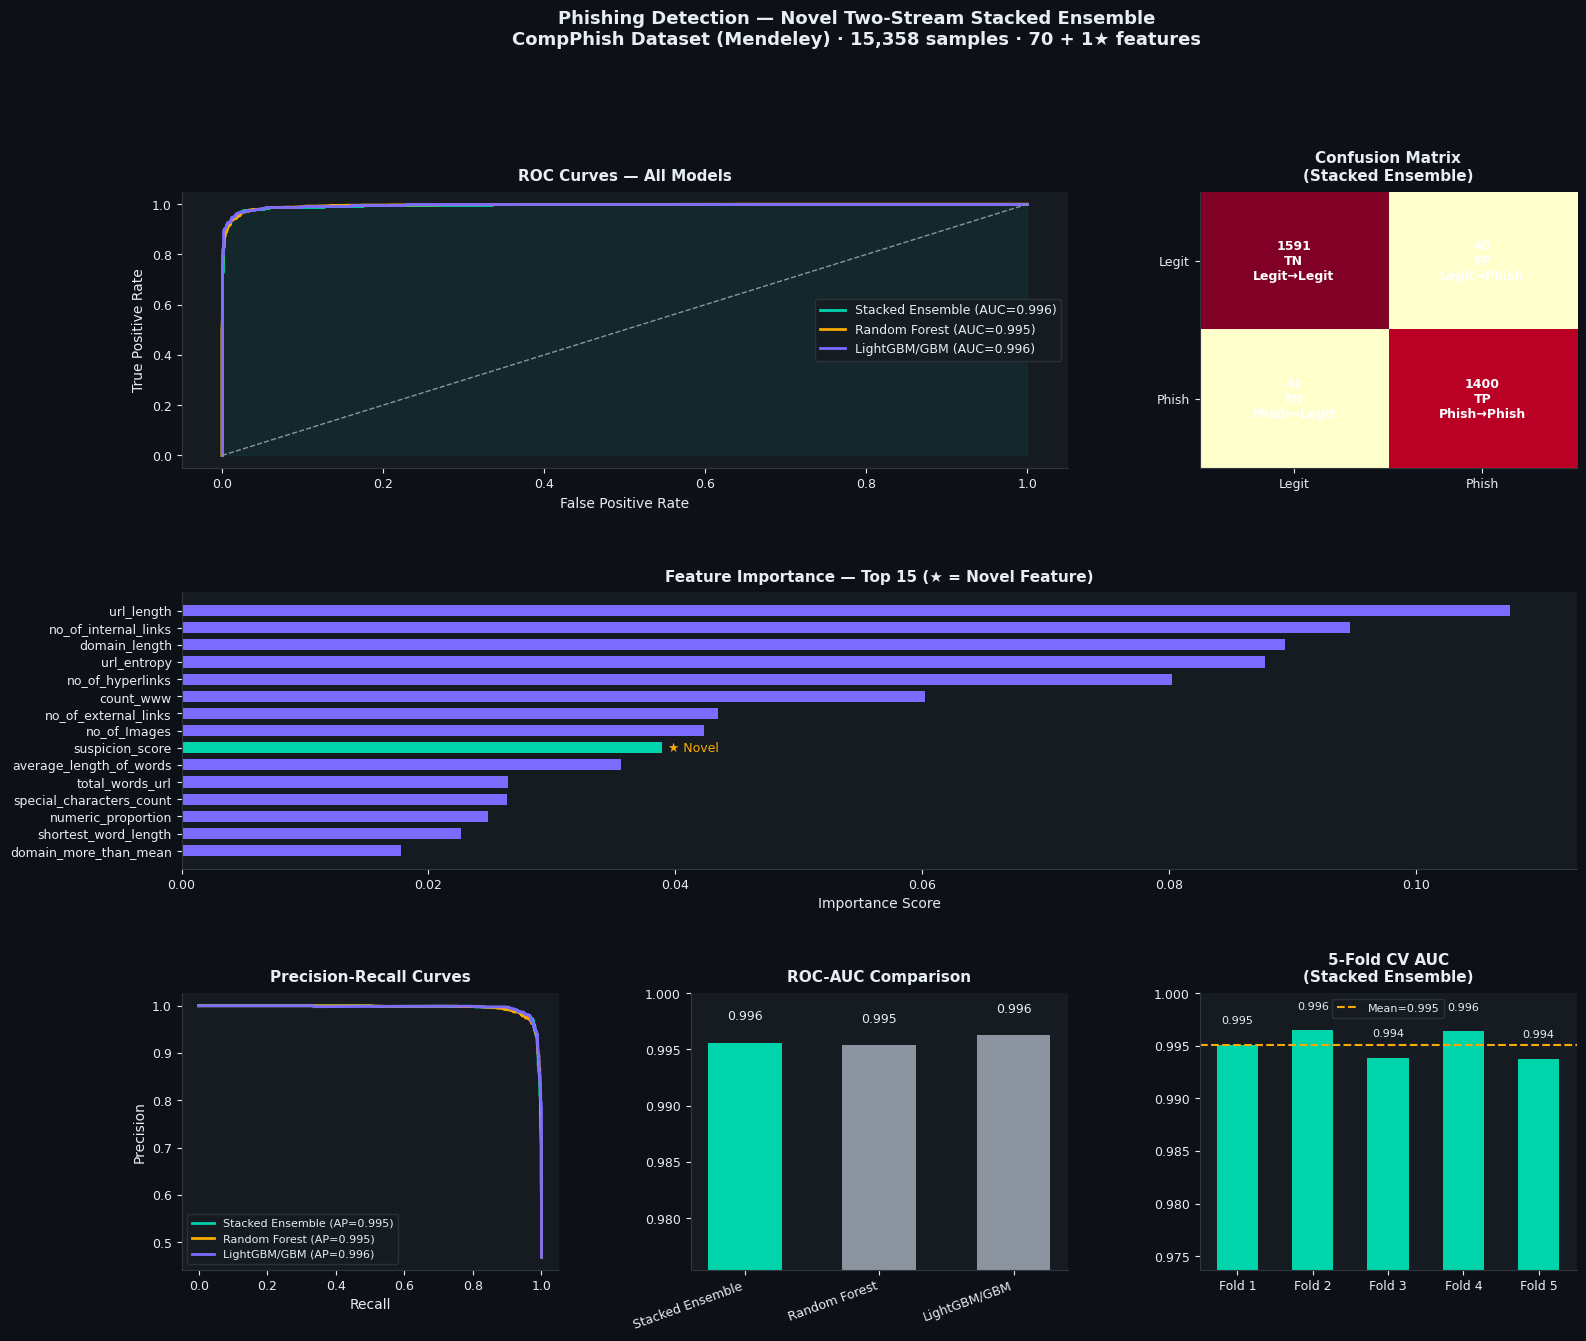


[OK] Results saved → phishing_results_FINAL.png


In [10]:
results = [
    ("Stacked Ensemble", prob_s, auc_s, ap_s, pred_s),
    ("Random Forest",    prob_r, auc_r, ap_r, pred_r),
    ("LightGBM/GBM",    prob_l, auc_l, ap_l, pred_l),
]

DARK    = "#0d1117"
BG2     = "#161b22"
TEXT    = "#e6edf3"
MUTED   = "#8b949e"
BORDER  = "#30363d"
GREEN   = "#00d4aa"
AMBER   = "#f7aa00"
PURPLE  = "#7c6bff"

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def ax_style(ax, title):
    ax.set_facecolor(BG2)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color(BORDER)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.set_title(title, color=TEXT, fontsize=11, pad=8, fontweight='bold')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)

COLORS = [GREEN, AMBER, PURPLE]

# 9a. ROC Curves
ax_roc = fig.add_subplot(gs[0, :2])
for (name, prob, auc, ap, _), col in zip(results, COLORS):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=col, lw=2)
ax_roc.plot([0,1],[0,1],'--',color=MUTED, lw=1)
fpr0, tpr0, _ = roc_curve(y_test, results[0][1])
ax_roc.fill_between(fpr0, tpr0, alpha=0.07, color=GREEN)
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(facecolor=BG2, edgecolor=BORDER, labelcolor=TEXT, fontsize=9)
ax_style(ax_roc, "ROC Curves — All Models")

# 9b. Confusion Matrix
ax_cm = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, pred_s)
ax_cm.imshow(cm, cmap='YlOrRd', aspect='auto')
labels = [["TN\nLegit→Legit", "FP\nLegit→Phish"],
          ["FN\nPhish→Legit", "TP\nPhish→Phish"]]
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f"{cm[i,j]}\n{labels[i][j]}",
                   ha='center', va='center', color='white',
                   fontsize=9, fontweight='bold')
ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(["Legit","Phish"], color=TEXT)
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(["Legit","Phish"], color=TEXT)
ax_style(ax_cm, "Confusion Matrix\n(Stacked Ensemble)")

# 9c. Feature Importance (from RF — works on all 71 features)
ax_fi = fig.add_subplot(gs[1, :])
fi    = rf_base.feature_importances_
idx   = np.argsort(fi)[-15:]
cols  = [ALL_FEATURES[i] for i in idx]
vals  = fi[idx]
bar_colors = [GREEN if 'suspicion' in c else PURPLE for c in cols]
ax_fi.barh(cols, vals, color=bar_colors, edgecolor='none', height=0.65)
ax_fi.set_xlabel("Importance Score")
for i, (c, v) in enumerate(zip(cols, vals)):
    if 'suspicion' in c:
        ax_fi.text(v + 0.0005, i, "★ Novel", color=AMBER, va='center', fontsize=9)
ax_style(ax_fi, "Feature Importance — Top 15 (★ = Novel Feature)")

# 9d. Precision-Recall
ax_pr = fig.add_subplot(gs[2, 0])
for (name, prob, auc, ap, _), col in zip(results, COLORS):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax_pr.plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=col, lw=2)
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.legend(facecolor=BG2, edgecolor=BORDER, labelcolor=TEXT, fontsize=8)
ax_style(ax_pr, "Precision-Recall Curves")

# 9e. AUC Bar
ax_bar = fig.add_subplot(gs[2, 1])
names  = [r[0] for r in results]
aucs   = [r[2] for r in results]
bclr   = [GREEN if i == 0 else MUTED for i in range(3)]
ax_bar.bar(names, aucs, color=bclr, edgecolor='none', width=0.55)
ax_bar.set_ylim(min(aucs) - 0.02, 1.0)
for i, v in enumerate(aucs):
    ax_bar.text(i, v + 0.002, f"{v:.3f}", ha='center', color=TEXT, fontsize=9)
ax_bar.set_xticklabels(names, rotation=20, ha='right', color=TEXT)
ax_style(ax_bar, "ROC-AUC Comparison")

# 9f. CV fold scores
ax_cv = fig.add_subplot(gs[2, 2])
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
ax_cv.bar(fold_labels, cv_scores, color=GREEN, edgecolor='none', width=0.55)
ax_cv.axhline(cv_scores.mean(), color=AMBER, lw=1.5, linestyle='--',
              label=f"Mean={cv_scores.mean():.3f}")
ax_cv.set_ylim(min(cv_scores) - 0.02, 1.0)
for i, v in enumerate(cv_scores):
    ax_cv.text(i, v + 0.002, f"{v:.3f}", ha='center', color=TEXT, fontsize=8)
ax_cv.legend(facecolor=BG2, edgecolor=BORDER, labelcolor=TEXT, fontsize=8)
ax_style(ax_cv, "5-Fold CV AUC\n(Stacked Ensemble)")

plt.suptitle(
    "Phishing Detection — Novel Two-Stream Stacked Ensemble\n"
    "CompPhish Dataset (Mendeley) · 15,358 samples · 70 + 1★ features",
    color=TEXT, fontsize=13, fontweight='bold', y=1.01
)
out = "phishing_results_FINAL.png"
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"\n[OK] Results saved → {out}")

## 10. SHAP Explainability


[SHAP] Computing feature attributions (URL stream) …


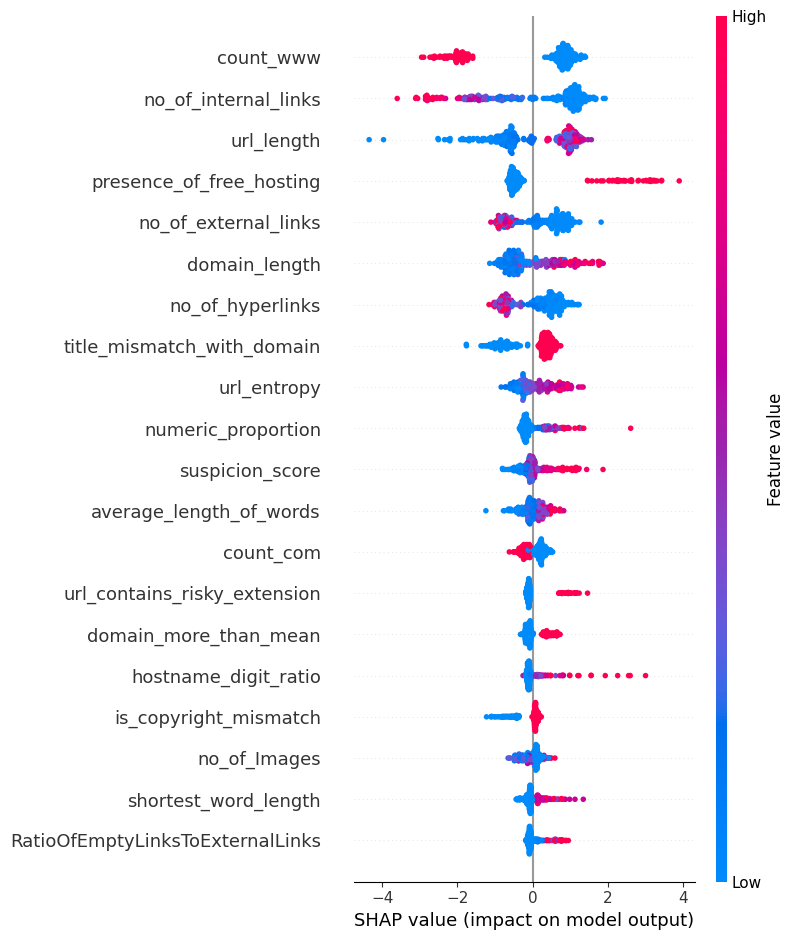

In [11]:
if HAS_SHAP:
    print("\n[SHAP] Computing feature attributions (URL stream) …")
    try:
        url_fitted = stacked.named_estimators_['url_stream']
        sample     = X_test_sc.iloc[:300]
        explainer  = shap.TreeExplainer(url_fitted)
        shap_vals  = explainer.shap_values(sample)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        shap.summary_plot(shap_vals, sample, feature_names=ALL_FEATURES, show=True)
    except Exception as e:
        print(f"[SHAP] Could not run: {e}")

## 11. Predict by Serial Number

Uses the Mapping File to verify a prediction against ground truth for a specific URL.

In [12]:
def predict_url(serial_number):
    """
    Given a serial_number, find the matching row in the dataset,
    run the stacked ensemble, and compare against the ground truth
    from the Mapping File.

    Use this to verify any specific URL — e.g. serial_number=2
    is https://www.google.com.hk/  → label=0 (Legitimate).
    """
    # Find the row in features dataframe
    row_df = df[df['serial_number'] == serial_number]
    if row_df.empty:
        print(f"[!] serial_number {serial_number} not found in dataset.")
        return

    # Ground truth from mapping file
    map_row   = mf[mf['serial_number'] == serial_number]
    true_url  = map_row['url'].values[0]  if not map_row.empty else "Unknown"
    true_label= map_row['label'].values[0] if not map_row.empty else row_df['label'].values[0]

    # Prepare feature vector
    feats  = row_df[ALL_FEATURES].copy()
    feats  = pd.DataFrame(imputer.transform(feats),  columns=ALL_FEATURES)
    feats  = pd.DataFrame(scaler.transform(feats),   columns=ALL_FEATURES)

    prob   = stacked.predict_proba(feats)[0, 1]
    pred   = int(prob >= 0.5)

    pred_label = "⚠ PHISHING"    if pred == 1  else "✓ LEGITIMATE"
    true_label_str = "PHISHING"   if true_label == 1 else "LEGITIMATE"
    match  = "✓ CORRECT" if pred == true_label else "✗ WRONG"

    print(f"\n{'='*60}")
    print(f"  Serial Number : {serial_number}")
    print(f"  URL           : {true_url}")
    print(f"  True Label    : {true_label} ({true_label_str})")
    print(f"  Phish Prob    : {prob:.4f}")
    print(f"  Prediction    : {pred} ({pred_label})")
    print(f"  Result        : {match}")
    print(f"{'='*60}")

# Test serial_number = 2  (google.com.hk → Legitimate)
predict_url(2)

# Test a few phishing samples (label=1)
phishing_samples = df[df['label'] == 1]['serial_number'].head(3).tolist()
for sn in phishing_samples:
    predict_url(sn)

print("\n[DONE] Full pipeline complete.")
print("       Outputs: phishing_results_FINAL.png")


  Serial Number : 2
  URL           : https://www.google.com.hk/
  True Label    : 0 (LEGITIMATE)
  Phish Prob    : 0.0119
  Prediction    : 0 (✓ LEGITIMATE)
  Result        : ✓ CORRECT

  Serial Number : 10100
  URL           : https://shaw-103179.square.site/
  True Label    : 1 (PHISHING)
  Phish Prob    : 0.9907
  Prediction    : 1 (⚠ PHISHING)
  Result        : ✓ CORRECT

  Serial Number : 10200
  URL           : http://aa.suk-ses.my.id/
  True Label    : 1 (PHISHING)
  Phish Prob    : 0.9706
  Prediction    : 1 (⚠ PHISHING)
  Result        : ✓ CORRECT

  Serial Number : 10400
  URL           : https://c-lk.in/gBzk
  True Label    : 1 (PHISHING)
  Phish Prob    : 0.9858
  Prediction    : 1 (⚠ PHISHING)
  Result        : ✓ CORRECT

[DONE] Full pipeline complete.
       Outputs: phishing_results_FINAL.png
